#Dataset selection:

In your project, you will pick a dataset (not the same as in the previous homeworks) and
describe the problem you would like to solve (classification or regression). Include a link to the
dataset source. It is highly recommended that you pick a dataset with at least 10,000 (or more
observations). There are many ways of describing a big dataset and one way to describe it is – a
big dataset is more complex. Complexity can refer to the number of observations, features, or
the type of data. For this project, there is no restriction on the number of features your dataset
has. However, having more features gives you greater ability to apply the techniques discussed
in class.


In this project I am looking at the CDC Diabetes Health Indicators dataset. It only has 21 features, but I selected it because it has over 250,000 intances. This is the type of big dataset that I think will be able to be utilized in the more complex neural network model. This will be a classification problem. Additinally, as a UCI dataset, it has been curate very well. There will be very little preprocessing required because there are no missing values, and all of the features are either integer values, or binary. They are primed for use already.

https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# metadata
print(cdc_diabetes_health_indicators.metadata)

# variable information
print(cdc_diabetes_health_indicators.variables)

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

In [ ]:
# split the data into a train, validation, and test set
from sklearn.model_selection import train_test_split
# because it is such a big dataset, only need 5% for validation and test sets
Xtrain, Xtemp, ytrain, ytemp = train_test_split(X, y, test_size=0.10)
Xval, Xtest, yval, ytest = train_test_split(Xtemp, ytemp, test_size=0.5)

In [ ]:
# preprocess by trainsposing for the class
XtrainNN = Xtrain.values.T
ytrainNN = ytrain.values.reshape(1, -1)

XvalNN = Xval.values.T
yvalNN = yval.values.reshape(1, -1)

In [ ]:
# normalize
mean = XtrainNN.mean(axis=1, keepdims=True)
std = XtrainNN.std(axis=1, keepdims=True) + 1e-10

XtrainNN = (XtrainNN - mean) / std
XvalNN = (XvalNN - mean) / std

#Part 1 (50 points)
In this part you will implement a neural network from scratch. You cannot use any existing
Deep Learning Framework. You can utilize NumPy and Pandas libraries to perform efficient
calculations. Refer to Lecture 5 slides for details on computations required.


In [ ]:
import numpy as np
import pandas as pd

Write a Class called NeuralNetwork that has at least the following methods (you are free to add
your own methods too):
1. Initialization method.
2. Forward propagation method that performs forward propagation calculations.
3. Backward propagation method that implements the backpropagation algorithm
discussed in class.
4. Train method that includes the code for gradient descent.
5. Cost method that calculates the loss function.
6. Predict method that calculates the predictions for the test set.

In [ ]:
class NeuralNetwork:
    def __init__(self, layers, activation='tanh'):
        """
        1. Initialization method
        layers: List containing the number of nodes in each layer
        activation: Activation function to use
        """
        self.layers = layers
        self.weights = [np.random.randn(layers[i+1], layers[i]) * 0.01 for i in range(len(layers)-1)]
        self.biases = [np.zeros((layers[i+1], 1)) for i in range(len(layers)-1)]

        if activation == 'tanh':
            self.activation = lambda x: np.tanh(x)
            self.d_activation = lambda x: 1 - np.tanh(x)**2
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forwardPropagation(self, X):
        """
        2. Forward propagation method
        """
        xLayers = [X]
        sLayers = []

        # iterate forward through layers
        for l in range(len(self.weights)):
            # finding the signals into the nodes
            s = np.dot(self.weights[l], xLayers[-1])
            s += self.biases[l]
            sLayers.append(s)

            # finding the outputs of the nodes
            if l == len(self.weights) - 1:
                x = self.sigmoid(s)
            else:
                x = self.activation(s)
            xLayers.append(x)

        return xLayers, sLayers

    def backPropagation(self, X, y, xLayers, sLayers):
        """
        3. Back propagation method
        """
        m = X.shape[1]
        # make the dW and db structures
        dW = [np.zeros_like(w) for w in self.weights]
        db = [np.zeros_like(b) for b in self.biases]

        # initialize the ouput layer
        delta = xLayers[-1] - y
        dW[-1] = np.dot(delta, xLayers[-2].T) / m
        db[-1] = np.mean(delta, axis=1, keepdims=True)

        # iterate backwards through the hidden layers
        for l in range(len(self.weights) - 2, -1, -1):
            delta = np.dot(self.weights[l + 1].T, delta) * self.d_activation(sLayers[l])
            dW[l] = np.dot(delta, xLayers[l].T) / m
            db[l] = np.mean(delta, axis=1, keepdims=True)

        return dW, db

    def cost(self, yhat, ytrue):
        """
        5. Cost using BCE
        """
        m = ytrue.shape[1]
        epsilon = 1e-10
        cost = -1/m * np.sum(ytrue * np.log(yhat + epsilon) + (1 - ytrue) * np.log(1 - yhat + epsilon))
        return cost

    def train(self, X, y, Xval, yval, epochs=10, batchSize=64, eta=0.01):
        """
        4. Train method using mini-batch gradient descent
        """
        n = X.shape[1]

        for epoch in range(epochs):
            # shuffle the data
            permutation = np.random.permutation(n)
            XShuffled = X[:, permutation]
            yShuffled = y[:, permutation]

            for i in range(0, n, batchSize):
                Xbatch = XShuffled[:, i:i+batchSize]
                ybatch = yShuffled[:, i:i+batchSize]

                xLayers, sLayers = self.forwardPropagation(Xbatch)
                dW, db = self.backPropagation(Xbatch, ybatch, xLayers, sLayers)

                for l in range(len(self.weights)):
                    self.weights[l] -= eta * dW[l]
                    self.biases[l] -= eta * db[l]

            # track progress
            trainPredictions, _ = self.forwardPropagation(X)
            validationPredictions, _ = self.forwardPropagation(Xval)

            trainLoss = self.cost(trainPredictions[-1], y)
            valLoss = self.cost(validationPredictions[-1], yval)

            print(f"Epoch {epoch+1}: Train Loss = {trainLoss}, Validation Loss = {valLoss}")

    def predict(self, X):
        """
        6. Predict method
        """
        xlayers, _ = self.forwardPropagation(X)
        return (xlayers[-1] >= 0.5).astype(int)

I implemented this in Machine Learning from Data. I kept the same methods but put everything into a class

Test your NeuralNetwork Class with the dataset you selected. If the dataset is big, you may
notice inefficiencies in runtime. Try incorporating different versions of gradient descent to
improve that (Minibatch, Stochastic etc.). You may choose to use only a subset of your data for
this task (or any other technique). Explain which technique you followed and why.

In [ ]:
model = NeuralNetwork([XtrainNN.shape[0], 12, 1])
model.train(XtrainNN, ytrainNN, XvalNN, yvalNN, epochs=20, batchSize=128, eta=0.05)

Epoch 1: Train Loss = 0.31773886541752305, Validation Loss = 0.3291601257112282
Epoch 2: Train Loss = 0.31684583733200744, Validation Loss = 0.3282349213499618
Epoch 3: Train Loss = 0.31599911507204664, Validation Loss = 0.3277320874673743
Epoch 4: Train Loss = 0.31508494220297084, Validation Loss = 0.32685576189676246
Epoch 5: Train Loss = 0.31431768146617445, Validation Loss = 0.3262198157278987
Epoch 6: Train Loss = 0.31382319438978956, Validation Loss = 0.3252649955521591
Epoch 7: Train Loss = 0.3134796181958637, Validation Loss = 0.3256689595809877
Epoch 8: Train Loss = 0.31303201989691976, Validation Loss = 0.32487036818282466
Epoch 9: Train Loss = 0.31282411334506255, Validation Loss = 0.3245821991379037
Epoch 10: Train Loss = 0.3125433316355104, Validation Loss = 0.32419725218712675
Epoch 11: Train Loss = 0.31229983841874326, Validation Loss = 0.3241303206610707
Epoch 12: Train Loss = 0.31228884943926877, Validation Loss = 0.3243446215146779
Epoch 13: Train Loss = 0.31205034517

I used minibatch. I think gradient descent would take too long to crawl over every point, and in stochastic, you are at risk of falling to randomness. Minibatch is a very nice comprimise. In terms of batch size, I thought 128 would be appropriate. It is small enough to create a stable gradient estimate, while still being large enough to run in a decent time.

In [ ]:
# evaluate on test set
XtestNN = Xtest.values.T
XtestNN = (XtestNN - mean) / std
ytestNN = ytest.values.reshape(1, -1)

accuracy = np.mean(model.predict(XtestNN) == ytestNN)
print(f"Final accuracy: {accuracy*100:.2f}%")

Final accuracy: 86.23%


#Part 2 (50 points)
In this part you will implement a 2-layer neural network using any Deep Learning Framework
(e.g., TensorFlow, PyTorch etc.).
You should pick a Deep Learning Framework that you would like to use to implement your 2-
layer Neural Network.

##Task 1 (5 points):
Assuming you are not familiar with the framework, in this part of the
homework you will present your research describing the resources you used to learn the
framework (must include links to all resources). Clearly explain why you needed a particular
resource for implementing a 2-layer Neural Network (NN). (Consider how you will keep track of
all the computations in a NN i.e., what libraries/tools do you need within this framework.)
For example, some of the known resources for TensorFlow and PyTorch are:
https://www.tensorflow.org/guide/autodiff
https://www.tensorflow.org/api_docs/python/tf/GradientTape
https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
Hint: You need to figure out the APIs/packages used to implement forward propagation and
backward propagation.


Resources used:

https://www.geeksforgeeks.org/deep-learning/how-to-implement-neural-networks-in-pytorch/

https://docs.pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html

https://www.pythonfaq.net/how-to-build-neural-networks-with-torch-nn-in-pytorch/

https://medium.com/@sahin.samia/mastering-the-basics-of-torch-nn-a-comprehensive-guide-to-pytorchs-neural-network-module-9f2d704e8c7f

https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html

https://www.codegenes.net/blog/pytorch-adam-neural-network/

The resouces used above helped me understand the beginner's best practices when it comes to neural networks. I will need to use the previously imported pandas and numpy libraries. Additionally, though it isn't neccessary, I very much like to use the sklearn train-test split because it makes the process a lot easier. Finally, the most important module for this task will be all of the torch imports that I intend to use. More specifically, the torch.nn. This import will allow me to do all of the calculations I did above when implementing a NN from scratch, with far fewer lines of code and more convinience. In that fold, I also will be using Adam for optimization, but that falls in with the other PyTorh resources.

Also, I use pyplot and seaborn for visualizing things.

##Task 2 (35 points):
Once you have figured out the resources you need for the project, you
should design and implement your project. The project must include the following steps (it’s
not limited to these steps):

NOTE: In this step, once you have implemented your 2-layer network you may increase and/or
decrease the number of layers as part of the hyperparameter tuning process.

1. Exploratory Data Analysis (Can include data cleaning, visualization etc.)


/tmp/ipython-input-1586476296.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diabetes_binary', data=edadf, palette='viridis')


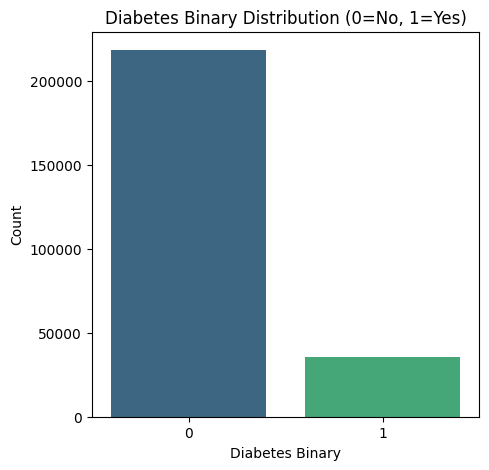

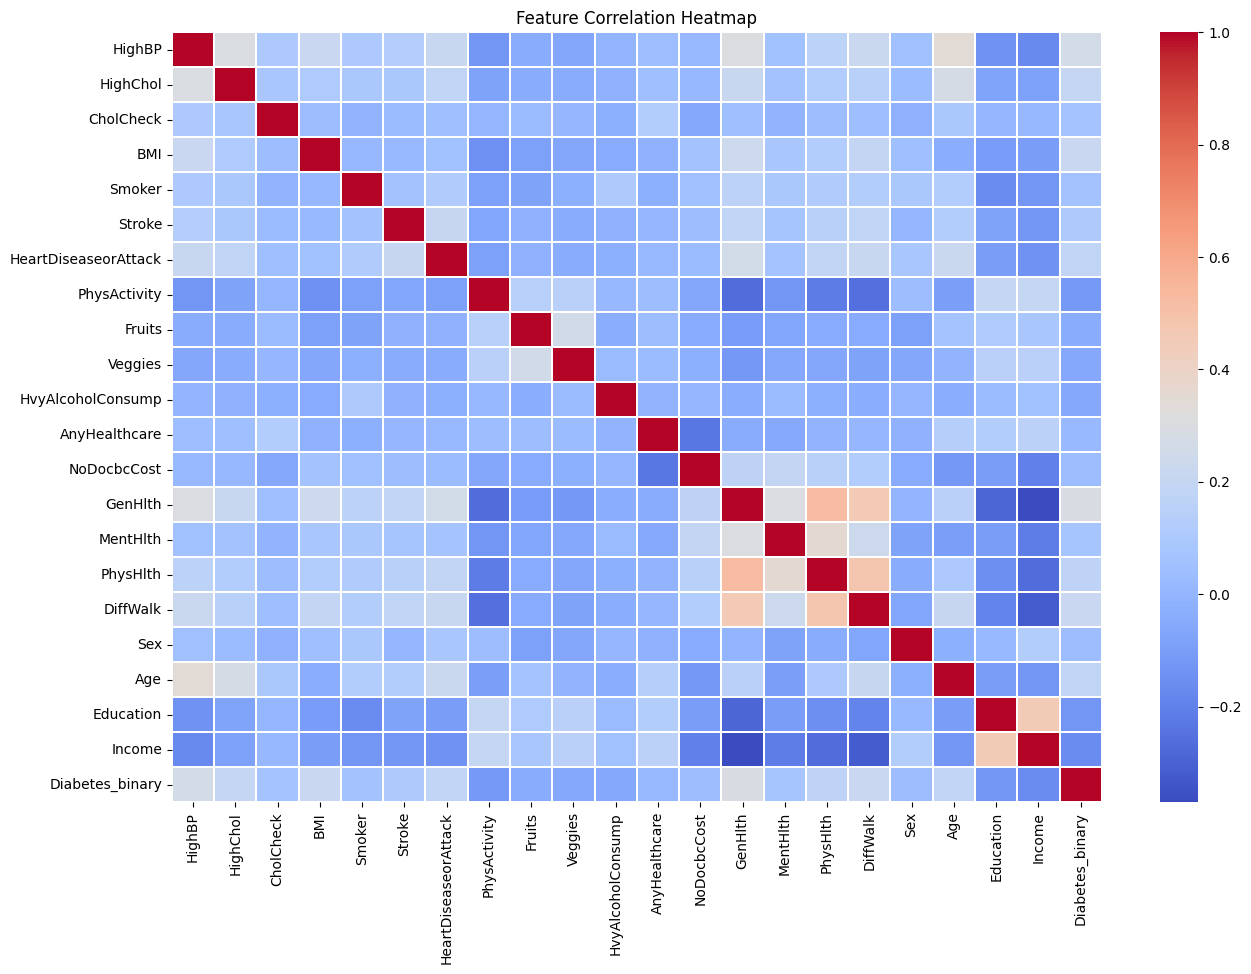

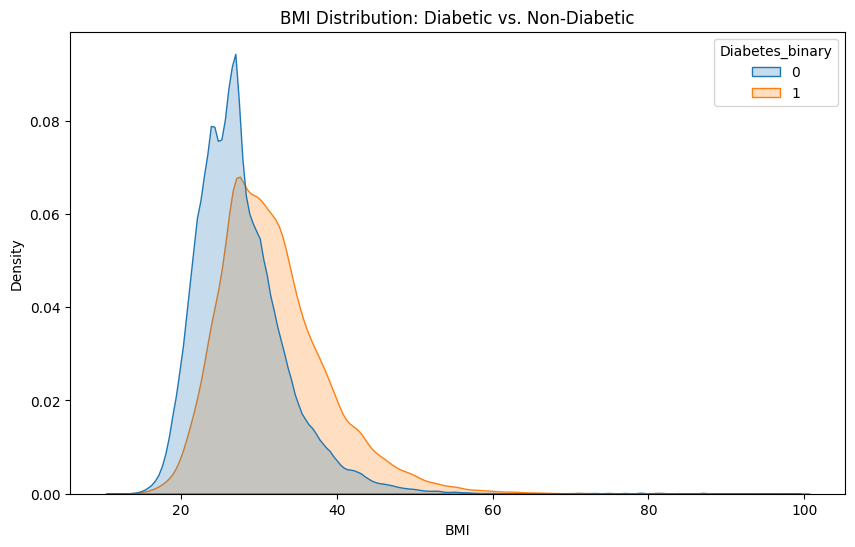

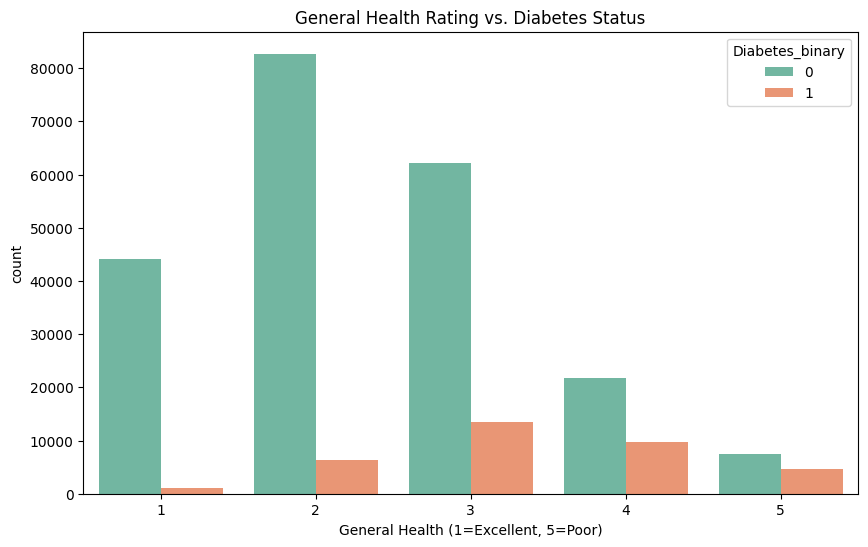

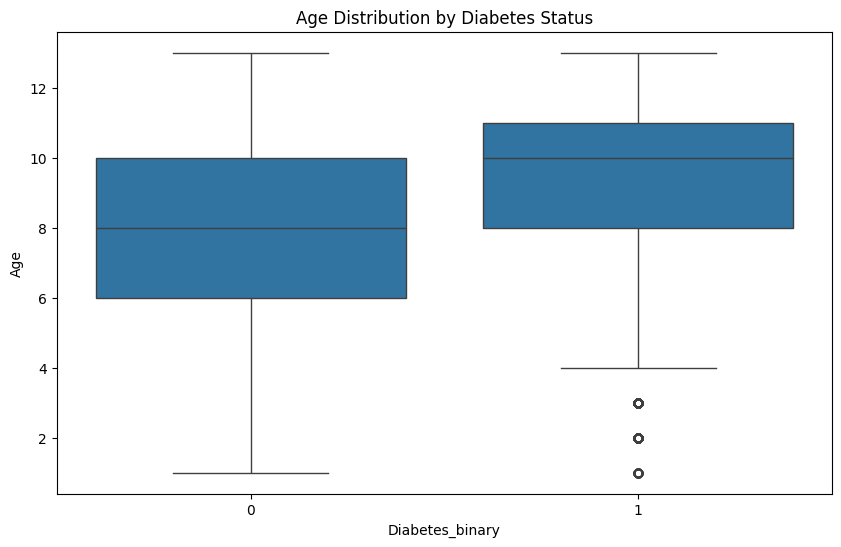

In [ ]:
# EDA
import seaborn as sns
import matplotlib.pyplot as plt

edadf = pd.concat([X, y], axis=1)

# plot of the target variable distribution, check for imbalance
plt.figure(figsize=(5, 5))
sns.countplot(x='Diabetes_binary', data=edadf, palette='viridis')
plt.title('Diabetes Binary Distribution (0=No, 1=Yes)')
plt.xlabel('Diabetes Binary')
plt.ylabel('Count')
plt.show()

# we can see which features have the strongest correlation with the target
plt.figure(figsize=(15, 10))
correlation = edadf.corr()
sns.heatmap(correlation, annot=False, cmap='coolwarm', linewidths=0.1)
plt.title('Feature Correlation Heatmap')
plt.show()

# BMI is often high in individuals with diabetes, we can see if this data reflects that
plt.figure(figsize=(10, 6))
sns.kdeplot(data=edadf, x='BMI', hue='Diabetes_binary', fill=True, common_norm=False)
plt.title('BMI Distribution: Diabetic vs. Non-Diabetic')
plt.show()

# see if poor health is associated with diabetes
plt.figure(figsize=(10, 6))
sns.countplot(x='GenHlth', hue='Diabetes_binary', data=edadf, palette='Set2')
plt.title('General Health Rating vs. Diabetes Status')
plt.xlabel('General Health (1=Excellent, 5=Poor)')
plt.show()

# the older you get, the higher risk you have. Again, we are checking to see if the data back that
plt.figure(figsize=(10, 6))
sns.boxplot(x='Diabetes_binary', y='Age', data=edadf)
plt.title('Age Distribution by Diabetes Status')
plt.show()

2. Perform a train-dev-test split.

Already performed this split above to run the NN from scratch

3. Implement forward propagation (clearly describe the activation functions and other
hyper-parameters you are using).

In [ ]:
import torch
import torch.nn as nn

class DiabetesNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(DiabetesNN, self).__init__()

        # first layer from input to hidden
        self.fc1 = nn.Linear(input_size, hidden_size)

        # second layer from hidden to output
        self.fc2 = nn.Linear(hidden_size, output_size)

        # activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        Forward propogation
        """
        # input to hidden
        out = self.fc1(x)
        out = self.relu(out)

        # hidden to output
        out = self.fc2(out)

        return out

# initialize the hyper-parameters
input_size = XtrainNN.shape[0]
hidden_size = 12
output_size = 1
learning_rate = 0.01

model = DiabetesNN(input_size, hidden_size, output_size)

The activation functions that I am using are ReLU and Sigmoid. I choose ReLU hear because it is a lot faster than tanh or sigmoid when doing the backpropogation. Also, I just learned that it was better in the hidden layers during my Data Mining class. Additionally, I used sigmoid for the output layer. I think it is appropriate here because it ensures that the output will be between 0 and 1, which is very helpful for a binary classification problem.

For the hyperparameters, the input size is the easiest choice. I am using 21 because that's how many features the dataseet has. Additionally, the output size of 1 is also pretty self explanatory. The hidden node size of 12 is where I had to make a judgement call. I thought that 12 would be a good mix wherer is is large enough to find the complexity in the model, but not too large as to overfit.

4. Compute the final cost function

In [ ]:
lossFunc = nn.BCEWithLogitsLoss()

5. Implement gradient descent (any variant of gradient descent depending upon your
data and project can be used) to train your model. In this step it is up to you as someone
in charge of their project to improvise using optimization algorithms (Adams, RMSProp
etc.) and/or regularization. Experiment with normalized inputs i.e. comment on how
your model performs when the inputs are normalized.


In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

XtrainT = torch.tensor(XtrainNN.T, dtype=torch.float32)
ytrainT = torch.tensor(ytrainNN.T, dtype=torch.float32)

XvalT = torch.tensor(XvalNN.T, dtype=torch.float32)
yvalT = torch.tensor(yvalNN.T, dtype=torch.float32)

train_dataset = TensorDataset(XtrainT, ytrainT)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.001)

# training loop
epochs = 20
for epoch in range(epochs):
    model.train()
    batch_losses = []
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        batch_loss = lossFunc(outputs, batch_y)

        # backward pass
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()

        batch_losses.append(batch_loss.item())

    model.eval()
    with torch.no_grad():
        val_outputs = model(XvalT)
        val_loss = lossFunc(val_outputs, yvalT)

    print(f"Epoch {epoch+1}/{epochs} - Batch Loss: {np.mean(batch_losses):.4f}, Validation Loss: {val_loss.item():.4f}")

Epoch 1/20 - Batch Loss: 0.3196, Validation Loss: 0.3266
Epoch 2/20 - Batch Loss: 0.3153, Validation Loss: 0.3255
Epoch 3/20 - Batch Loss: 0.3150, Validation Loss: 0.3252
Epoch 4/20 - Batch Loss: 0.3150, Validation Loss: 0.3252
Epoch 5/20 - Batch Loss: 0.3151, Validation Loss: 0.3274
Epoch 6/20 - Batch Loss: 0.3149, Validation Loss: 0.3259
Epoch 7/20 - Batch Loss: 0.3150, Validation Loss: 0.3252
Epoch 8/20 - Batch Loss: 0.3151, Validation Loss: 0.3257
Epoch 9/20 - Batch Loss: 0.3151, Validation Loss: 0.3258
Epoch 10/20 - Batch Loss: 0.3149, Validation Loss: 0.3247
Epoch 11/20 - Batch Loss: 0.3150, Validation Loss: 0.3256
Epoch 12/20 - Batch Loss: 0.3149, Validation Loss: 0.3248
Epoch 13/20 - Batch Loss: 0.3149, Validation Loss: 0.3273
Epoch 14/20 - Batch Loss: 0.3149, Validation Loss: 0.3246
Epoch 15/20 - Batch Loss: 0.3150, Validation Loss: 0.3285
Epoch 16/20 - Batch Loss: 0.3151, Validation Loss: 0.3247
Epoch 17/20 - Batch Loss: 0.3151, Validation Loss: 0.3255
Epoch 18/20 - Batch Los

My inputs have been normalized from the start. This is a very important requirement when building NNs because it can be very hard to have a model converge with un-normalized features.

Additionally, with my mix of integer and binary features, the binary features would get drowned out. The integer features when unprocessed, just have values that are so much greater.

6. Present the results using the test set.

In [ ]:
model.eval()
with torch.no_grad():
    XtestT = torch.tensor(XtestNN.T, dtype=torch.float32)
    ytestT = torch.tensor(ytestNN.T, dtype=torch.float32)

    test_outputs = model(XtestT)
    predictions = (torch.sigmoid(test_outputs) >= 0.5).float()

    accuracy = (predictions == ytestT).sum() / len(ytestT)
    print(f"Test Accuracy: {accuracy.item() * 100:.2f}%")

Test Accuracy: 86.16%


##Task 3 (10 points):
In task 2 describe how you selected the hyperparameters. What was the
rationale behind the technique you used? Did you use regularization? Why, or why not? Did you use
an optimization algorithm? Why or why not?

We have already discussed the choices for the various layer sizes. The next important hyperparameter is the learning rate, eta. I selected 0.01. This is a well balanced selection. If I were to increase to 0.1, the validation loss would flocuate too much. However, if I were to go with a learning rate of just 0.001, then it would take too long to converge considering the extreme quantity of data points. In terms of batch size, again, I felt 128 would be appropriate. It is small enough to create a stable gradient estimate, while still being large enough to benefit from the vectorization built into PyTorch.

For regularization, I used the weight decay parameter in Adam. In a large datset with many binary features, exactly like the one that I am using, you run the risk of certain weights becoming very extreme as the neural network tries to account for all of the outliers in the training data. The weight decay leads to smaller weights and a less complex decision boudary. This means that the resulting boundary will generalize to the validation and test sets better as it did not go too extreme into learning the patterns that only exist in the training data.

For optimization, as you could gather from the last cell, I used Adam. I choose this over a standard SGD. I chose Adam because its ability to continue to change the learning rates for each paramter is especially powerful and important for a model like mine where we are analyzing so many features. It ensures that the signals that are less frequently seen, but still important, get found and don't just get washed out.

Beyond the benefits of Adam, there are some known flaws with SGD. The biggest issue is where the SGD can get stuck in flat parts of the data, whereas Adam is built to accelearate through these. This will allow for a much quicker convergance without sacrificing accuracy.

##Task 4 (100 points):
Create another baseline model (can be any model we covered so far except
a deep learning model). Using the same training data (as above) train your model and evaluate
results using the test set. Compare the results of both models (the Neural Network and the
baseline model). What are the reasons for one model performing better (or not) than the
other? Explain.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# I am using the parameters I went with in previous homeworks
baseline_model = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)

baseline_model.fit(Xtrain, ytrain.values.ravel())

# results on test set
yhat = baseline_model.predict(Xtest)
baseline_accuracy = accuracy_score(ytest, yhat)

print(f"Baseline (Random Forest) Accuracy: {baseline_accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(ytest, yhat))

Baseline (Random Forest) Accuracy: 86.11%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.92     10860
           1       0.63      0.08      0.15      1824

    accuracy                           0.86     12684
   macro avg       0.75      0.54      0.54     12684
weighted avg       0.83      0.86      0.81     12684



They have resulted in nearly the exact same accuracy. In fact, every model that I have run on this dataset has ended with an accuracy of low 86%. It terms of the models, the NN is far more complex, and is harder for a general person in the health field to understand why it is making its decisions. That can be part of the consideration why it may be better. However, on the other hand, if more data were to be collected on this problem, that had a more complex pattern, I would trust the NN to find that pattern more consistently than the logistic regression. In either case, despite the vastly different inner workings of the model, we appear to be hitting a plateau in any machine's capability to predict this dataset.